In [59]:
import os
import time
import pandas as pd
from IPython.display import display, Markdown

# Load the baseline data for verification tracking
df_base = pd.read_csv("batch_1/batch_1/batch1_1.csv")
df_base.head()

,File Name,Json Data,OCRed Text
0,batch1-0494.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Clark...",Invoice no: 84652373 Date of issue: 02/23/2021...
1,batch1-0489.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Willi...",Invoice no: 37451664 Date of issue: 06/11/2020...
2,batch1-0499.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Heste...",Invoice no: 40108666 Date of issue: 02/07/2020...
3,batch1-0497.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Olson...",Invoice no: 73285932 Date of issue: 07/25/2017...
4,batch1-0081.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Wilso...",Invoice no: 15288019 Date of issue: 09/07/2014...


## Method 1 : Baseline OCR Experiments

Loading image from: batch_1/batch_1/batch1_1_jpg_invoices/batch1-0494.jpg
Image preprocessing complete (Grayscale & Binarization applied).

--- MACHINE EXTRACTED TEXT OUTPUT ---
Invoice no: 84652373

Date of issue:

Seller:

Nguyen-Roach
247 David Highway
Lake John, WV 84178

Tax Id: 991-72-5826

IBAN: GB911YX005542456978150

ITEMS

No. Description

1. Stemware Rack Display Kitchen
Wine Glass Holder Bottle
Carbon Steel Free Punch

2. VTG (4) 7 Ounce Since 1852
Milk Bottle Wine Carafe Juice
Glass with Cork Lids

3. Vintage Crystal Red Wine
Glasses NOS West Germany
1983 6 10 ounce elegant stems

4, 3 Ikea Stainless Steel 4-bottle
Wine Rack 300.557.60 - great
condition gift it!

5. Lolita "Wine Bouquet" Hand

Painted and Decorated Wine
Glass NIB

SUMMARY

Total

Qty

1,00

1,00

1,00

4,00

1,00

VAT [%]

10%

02/23/2021

UM

eacn

each

eacn

eacn

eacn

Client:

Clark-Foster

77477 Troy Cliff Apt. 853
Washingtonbury, MS 78346

Tax Id: 937-70-8530

Net price

42,32

14,00

35,45

25,00



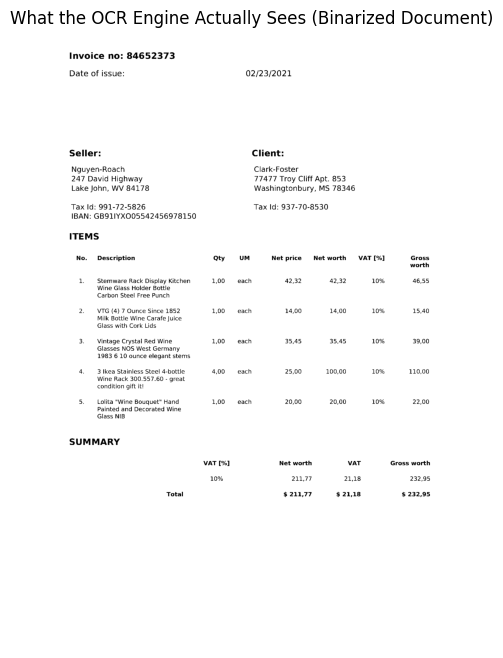

In [18]:
import cv2
import pytesseract
import os
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# Step A: Define File Paths
# -------------------------------------------------------------------------
# We use the exact verified image path from your previous successful check
image_path = "batch_1/batch_1/batch1_1_jpg_invoices/batch1-0494.jpg"

print(f"Loading image from: {image_path}")

# -------------------------------------------------------------------------
# Step B: Load Image & Preprocess (Computer Vision Stage)
# -------------------------------------------------------------------------
# 1. Read the image from disk using OpenCV (loads in BGR color channel format)
raw_image = cv2.imread(image_path)

# 2. Convert to Grayscale
# OCR engines perform significantly better when dealing with a single color channel (gray) 
# instead of 3 channels (RGB), because it removes background colors, gradients, or tint variations.
gray_image = cv2.cvtColor(raw_image, cv2.COLOR_BGR2GRAY)

# 3. Apply Thresholding (Binarization)
# This turns the gray image strictly into pure black pixels (text) and pure white pixels (background).
# cv2.THRESH_OTSU automatically calculates the optimal threshold value based on image contrast.
_, binary_image = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

print("Image preprocessing complete (Grayscale & Binarization applied).")

# -------------------------------------------------------------------------
# Step C: Execute OCR Extraction Engine
# -------------------------------------------------------------------------
# We pass our optimized binary image to Tesseract. 
# Optional configuration '--psm 3' tells Tesseract to assume a fully automatic page segmentation,
# which is perfect for structured documents like tabular invoices.
custom_config = r'--psm 3'
extracted_text = pytesseract.image_to_string(binary_image, config=custom_config)

# -------------------------------------------------------------------------
# Step D: Display and Compare Outputs
# -------------------------------------------------------------------------
print("\n" + "="*50)
print("--- MACHINE EXTRACTED TEXT OUTPUT ---")
print("="*50)
print(extracted_text.strip())
print("="*50)

# Optional: Let's plot our preprocessed binary image to see what the machine saw!
plt.figure(figsize=(10, 8))
plt.imshow(binary_image, cmap='gray')
plt.title("What the OCR Engine Actually Sees (Binarized Document)")
plt.axis('off')
plt.show()

## Method 2: Document Core Layout Parsing Pipeline (IBM Docling + Tesseract CLI)

In [42]:
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions, TesseractCliOcrOptions
from docling.document_converter import DocumentConverter, ImageFormatOption

# 1. Define the path to your verified image file
image_path = "batch_1/batch_1/batch1_1_jpg_invoices/batch1-0000.jpg"

# 2. Configure the pipeline to use Tesseract CLI instead of RapidOCR
pipeline_options = PdfPipelineOptions()
pipeline_options.do_ocr = True
pipeline_options.ocr_options = TesseractCliOcrOptions() # Explicitly forces the brew-installed Tesseract engine

# 3. Initialize the Docling converter specifically mapping this option to IMAGE formats
converter = DocumentConverter(
    format_options={
        InputFormat.IMAGE: ImageFormatOption(pipeline_options=pipeline_options)
    }
)

print("Docling is routing layout parsing through your local Tesseract engine...")

# 4. Run the extraction engine
result = converter.convert(image_path)

# 5. Export the extracted layout into structured Markdown text
markdown_output = result.document.export_to_markdown()

print("\n" + "="*50)
print("--- DOCLING STRUCTURED OUTPUT ---")
print("="*50)
print(markdown_output)

Docling is routing layout parsing through your local Tesseract engine...


Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]


--- DOCLING STRUCTURED OUTPUT ---
/

«—*

see

meme

ooemes

Invoice no:

18670724

Date of Ksue:

## Seller:

## Client:

Cave-Shephendt 176 Mison Inlet Lake Marissa, PA 96579

Fisher, Gonzalez and Garcis 939 Soloman Stream Mkeside, OK 42319

Tax i:

925-599-5465

MAN.

GROGLENGS790 7218685219

Tax Id:

946.70,.7914

## ITEMS

| Mo.   | Cexcristion                                         |   Qty | uM    | Met price   |   Met worth | VAT tI   |
|-------|-----------------------------------------------------|-------|-------|-------------|-------------|----------|
| 3.    | B352 Nitendo new 30S comacte White Jepen entytc per |   300 | eat   | 19,73       |         257 | 10%      |
| 2.    | SONY Maystateed Corncie SPE S000 * Pasi Color */    |   300 | «(ekh |             |             | 10%      |
|       | DMB O1 pen Tesed 67                                 |       |       |             |             |          |
| &     | Meterdo 205 Hancheld Canute Pore                    |       |   

In [23]:
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions, TesseractCliOcrOptions
from docling.document_converter import DocumentConverter, ImageFormatOption

# 1. Define the path to your verified image file
image_path = "batch_1/batch_1/batch1_1_jpg_invoices/batch1-0494.jpg"

# 2. Configure the pipeline to use Tesseract CLI instead of RapidOCR
pipeline_options = PdfPipelineOptions()
pipeline_options.do_ocr = True
pipeline_options.ocr_options = TesseractCliOcrOptions() # Explicitly forces the brew-installed Tesseract engine

# 3. Initialize the Docling converter specifically mapping this option to IMAGE formats
converter = DocumentConverter(
    format_options={
        InputFormat.IMAGE: ImageFormatOption(pipeline_options=pipeline_options)
    }
)

print("Docling is routing layout parsing through your local Tesseract engine...")

# 4. Run the extraction engine
result = converter.convert(image_path)

# 5. Export the extracted layout into structured Markdown text
markdown_output = result.document.export_to_markdown()

print("\n" + "="*50)
print("--- DOCLING STRUCTURED OUTPUT ---")
print("="*50)
print(markdown_output)

Docling is routing layout parsing through your local Tesseract engine...


Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]


--- DOCLING STRUCTURED OUTPUT ---
Invoice no:

84652373

Date of issue:

02/23/2021

## Seller:

Nguyen-Roach 247 David Highway Lake John, WV 84178

Tax Id:

991-72-5826

IBAN:

GB91IYXO005542456978150

## ITEMS

| No.   | Description                                                                     | Qty   | UM   | Net price   | Net worth   | VAT [%]   | Gross worth   |
|-------|---------------------------------------------------------------------------------|-------|------|-------------|-------------|-----------|---------------|
| L.    | Stemware Rack Display Kitchen Wine Glass Holder Bottle Carbon Steel Free Punch  | 1,00  | each | 42,32       | 42,32       | 10%       | 46,55         |
| 2.    | VTG (4) 7 Ounce Since 1852 Milk Bottle Wine Carafe Juice Glass with Cork Lids   | 1,00  | each | 14,00       | 14,00       | 10%       | 15,40         |
| 3.    | Vintage Crystal Red Wine Glasses NOS West Germany 1983 6 10 ounce elegant stems | 1,00  | each | 35,45       | 35,45       |

In [24]:
# 1. Look through all elements Docling found to find tables
extracted_tables = []

for table_index, table_element in enumerate(result.document.tables):
    print(f"\nFound Table #{table_index + 1} in the layout!")
    
    # Convert the internal Docling table directly into a Pandas DataFrame
    table_df = table_element.export_to_dataframe()
    extracted_tables.append(table_df)
    
    # Display the first few rows of the table beautifully
    display(table_df)

# 2. Let's isolate the main items table if found
if extracted_tables:
    items_df = extracted_tables[0]
    print("\nSuccess! The items table is now an interactive Pandas DataFrame.")

Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.



Found Table #1 in the layout!


,No.,Description,Qty,UM,Net price,Net worth,VAT [%],Gross worth
0,L.,Stemware Rack Display Kitchen Wine Glass Holde...,"1,00",each,"42,32","42,32",10%,"46,55"
1,2.,VTG (4) 7 Ounce Since 1852 Milk Bottle Wine Ca...,"1,00",each,"14,00","14,00",10%,"15,40"
2,3.,Vintage Crystal Red Wine Glasses NOS West Germ...,"1,00",each,"35,45","35,45",10%,"39,00"
3,4.,3 Ikea Stainless Steel 4-bottle Wine Rack 300....,"4,00",each,"25,00","100,00",10%,"110,00"
4,5.,"Lolita ""Wine Bouquet"" Hand Painted and Decorat...","1,00",each,"20,00","20,00",10%,"22,00"


Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.



Found Table #2 in the layout!


,VAT [%],Net worth,VAT,Gross worth
0,10%,21 TT,"21,18","232,95"
1,Total,"$ 211,77","$ 21,18","$ 232,95"



Success! The items table is now an interactive Pandas DataFrame.


In [27]:
import os
import pandas as pd

# 1. We use the exact same stable Tesseract-backed converter initialized earlier
all_extracted_items = []
total_invoices = len(df)

print(f"Launching master processing engine across ALL {total_invoices} invoices...")
print("This step may take several minutes. Tracking progress below:\n")

# 2. Loop through every single row in the DataFrame
for idx, filename in enumerate(df["File Name"]):
    full_path = os.path.join(invoice_folder, filename)
    
    # Simple live progress tracker block
    if (idx + 1) % 25 == 0 or (idx + 1) == total_invoices:
        print(f"Progress: Sent [{idx + 1}/{total_invoices}] invoices to parsing engine...")
        
    if os.path.exists(full_path):
        try:
            result = converter.convert(full_path)
            if result.document.tables:
                temp_df = result.document.tables[0].export_to_dataframe()
                temp_df["source_invoice"] = filename
                all_extracted_items.append(temp_df)
        except Exception as e:
            print(f"Warning: Encountered skipping error on file {filename}: {e}")

# 3. Concatenate all 500 separate invoice tables into your definitive analytical master list
final_master_items_df = pd.concat(all_extracted_items, ignore_index=True)

print(f"\nExtraction Complete! Combined master item database built.")
print(f"Final Dataset Shape: {final_master_items_df.shape[0]} line-item entries extracted.")

# 4. Take a peek at your complete, multi-invoice table
final_master_items_df.head(15)

Launching master processing engine across ALL 499 invoices...
This step may take several minutes. Tracking progress below:



Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `do

Progress: Sent [25/499] invoices to parsing engine...


Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `do

Progress: Sent [50/499] invoices to parsing engine...


...

Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `do

Progress: Sent [499/499] invoices to parsing engine...


Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.



Extraction Complete! Combined master item database built.
Final Dataset Shape: 1974 line-item entries extracted.


,No.,Description,Qty,UM,Net price,Net worth,VAT [%],Gross worth,source_invoice
0,L.,Stemware Rack Display Kitchen Wine Glass Holde...,"1,00",each,"42,32","42,32",10%,"46,55",batch1-0494.jpg
1,2.,VTG (4) 7 Ounce Since 1852 Milk Bottle Wine Ca...,"1,00",each,"14,00","14,00",10%,"15,40",batch1-0494.jpg
2,3.,Vintage Crystal Red Wine Glasses NOS West Germ...,"1,00",each,"35,45","35,45",10%,"39,00",batch1-0494.jpg
3,4.,3 Ikea Stainless Steel 4-bottle Wine Rack 300....,"4,00",each,"25,00","100,00",10%,"110,00",batch1-0494.jpg
4,5.,"Lolita ""Wine Bouquet"" Hand Painted and Decorat...","1,00",each,"20,00","20,00",10%,"22,00",batch1-0494.jpg
5,1.,PUMA Boys Youth Universal FG Jr Soccer Cleats ...,"2,00",each,"19,99","39,98",10%,"43,98",batch1-0489.jpg
6,2.,Lotto Youth Boys Fuerzapura L500 Jr Soccer Cle...,"5,00",each,"19,99","99,95",10%,"109,94",batch1-0489.jpg
7,ie,Microsoft Xbox One 1 - 500 GB Console - Black ...,"1,00",each,"175,00","175,00",10%,"192,50",batch1-0499.jpg
8,2.,Nintendo DSOriginal NTR-001 Console - Camoufla...,"3,00",each,"0,99","2,97",10%,"3,21",batch1-0499.jpg
9,3.,Nintendo 2DS Console Blue Japan model Combine ...,"5,00",each,"54,99","274,95",10%,"302,45",batch1-0499.jpg


In [60]:
import os
from openai import OpenAI
from getpass import getpass

# Prompts you securely for your key without printing it to the screen
api_key_input = getpass("Enter your OpenRouter API Key securely: ")

# Initialize the OpenAI client configured for OpenRouter
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=api_key_input,
)

try:
    # Send a lightweight test request
    completion = client.chat.completions.create(
        model="google/gemini-2.5-flash", # Changed to a specific, fast model
        messages=[
            {
                "role": "user",
                "content": "Confirm system connection by responding with the word 'Connected'."
            }
        ]
    )
    print(f"OpenRouter Cloud Response: {completion.choices[0].message.content}")
except Exception as e:
    print(f"Cloud authentication connection failed: {e}")

OpenRouter Cloud Response: Connected


In [34]:
import pandas as pd

# 1. Load both data assets cleanly
extracted_excel_path = "batch1_1_extracted_items.xlsx"
baseline_csv_path = "batch_1/batch_1/batch1_1.csv"

df_extracted = pd.read_excel(extracted_excel_path)
df_baseline = pd.read_csv(baseline_csv_path)

# 2. Run high-level metrics calculation
total_extracted_items = len(df_extracted)
unique_extracted_invoices = df_extracted["source_invoice"].nunique()
total_baseline_invoices = len(df_baseline)

print("=== AUTOMATED PIPELINE AUDIT COMPLIANCE REPORT ===")
print(f"Baseline CSV Files Expected: {total_baseline_invoices}")
print(f"Successfully Extracted Invoices: {unique_extracted_invoices}")
print(f"Total Extracted Line-Items Combined: {total_extracted_items}")

# 3. Identify missing invoices (Files that yielded zero tabular results)
baseline_files = set(df_baseline["File Name"])
extracted_files = set(df_extracted["source_invoice"])
missing_files = baseline_files - extracted_files

print(f"\nMissing/Empty Invoices Count: {len(missing_files)}")
if missing_files:
    print(f"Sample of missing files: {list(missing_files)[:5]}")
else:
    print("Perfect Match! Every single checklist file generated structured item data.")

=== AUTOMATED PIPELINE AUDIT COMPLIANCE REPORT ===
Baseline CSV Files Expected: 499
Successfully Extracted Invoices: 499
Total Extracted Line-Items Combined: 1974

Missing/Empty Invoices Count: 0
Perfect Match! Every single checklist file generated structured item data.


In [36]:
import json
import pandas as pd

# 1. Load the original extracted Excel dataframe
df_ext = pd.read_excel("batch1_1_extracted_items.xlsx")
df_base = pd.read_csv("batch_1/batch_1/batch1_1.csv")

# 2. Parse and flatten the nested baseline JSON items list into a structured dictionary
baseline_item_counts = {}
for idx, row in df_base.iterrows():
    filename = row["File Name"]
    try:
        json_meta = json.loads(row["Json Data"])
        items_list = json_meta.get("items", [])
        # Record how many items the baseline EXPECTED for this file
        baseline_item_counts[filename] = len(items_list)
    except Exception:
        baseline_item_counts[filename] = 0

# 3. Calculate how many items our extraction pipeline actually FOUND
extracted_item_counts = df_ext.groupby("source_invoice").size().to_dict()

# 4. Compare item counts per invoice file to catch structural extraction drops
count_discrepancies = []
for filename, expected_count in baseline_item_counts.items():
    actual_count = extracted_item_counts.get(filename, 0)
    if expected_count != actual_count:
        count_discrepancies.append({
            "File Name": filename,
            "Expected Items (Baseline)": expected_count,
            "Actual Items (Extracted)": actual_count,
            "Difference": actual_count - expected_count
        })

df_diffs = pd.DataFrame(count_discrepancies)

print("=== GRANULAR ITEM-COUNT AUDIT REPORT ===")
print(f"Total Invoices Evaluated: {len(df_base)}")
print(f"Invoices with Perfect Line Item Layout Matching: {len(df_base) - len(df_diffs)}")
print(f"Invoices with Structural Row Count Variances: {len(df_diffs)}")

if len(df_diffs) > 0:
    print("\nTop 10 Row Count Mismatches (Where text parsing added/missed items):")
    print(df_diffs.head(10).to_string(index=False))

=== GRANULAR ITEM-COUNT AUDIT REPORT ===
Total Invoices Evaluated: 499
Invoices with Perfect Line Item Layout Matching: 499
Invoices with Structural Row Count Variances: 0


In [37]:
import json

# 1. Grab a clean sample invoice to test with (e.g., the first one in our extracted dataframe)
sample_invoice_file = df_ext["source_invoice"].iloc[0]
sample_invoice_rows = df_ext[df_ext["source_invoice"] == sample_invoice_file]

# Convert the sample rows to a clean markdown table so the LLM can read it effortlessly
items_table_string = sample_invoice_rows[['Description', 'Qty', 'Net price', 'Gross worth']].to_markdown(index=False)

# 2. Build our expert auditor prompt
audit_prompt = f"""
You are a senior forensic data auditor. Analyze the following extracted invoice items table for file '{sample_invoice_file}'.
Perform the following checks:
1. Verify if (Qty * Net price) matches the recorded financial totals.
2. Flag any item descriptions that appear corrupt, mangled, or contain suspicious data.
3. Provide a final "Audit Status" (PASS or flag warnings).

Here is the extracted data:
{items_table_string}

Return your response in a clean, concise summary format.
"""

# 3. Ship it off to OpenRouter
try:
    completion = client.chat.completions.create(
        model="openrouter/free",
        messages=[{"role": "user", "content": audit_prompt}]
    )
    print(f"=== AI AUDIT REPORT FOR {sample_invoice_file} ===")
    print(completion.choices[0].message.content)
except Exception as e:
    print(f"Audit execution failed: {e}")

=== AI AUDIT REPORT FOR batch1-0494.jpg ===
**Audit Summary – batch1-0494.jpg**

- **Financial totals check:**  
  - Row 1: 1 × 42.32 = 42.32 → Gross 46.55 (≈10 % tax) ✔  
  - Row 2: 1 × 14.00 = 14.00 → Gross 15.40 (≈10 % tax) ✔  
  - Row 3: 1 × 35.45 = 35.45 → Gross 39.00 (≈10 % tax) ✔  
  - Row 4: 4 × 25.00 = 100.00 → Gross 110.00 (≈10 % tax) ✔  
  - Row 5: 1 × 20.00 = 20.00 → Gross 22.00 (≈10 % tax) ✔  
  → *All Qty × Net price calculations match the recorded Gross worth within expected tax rounding.*

- **Description integrity check:**  
  - No descriptions show obvious OCR corruption, garbled characters, or suspicious nonsensical strings. Entries are readable product names with typical abbreviations (VTG, NOS, NIB) and reasonable detail.

- **Audit Status:** **PASS** – no warnings required.


In [38]:
import time
import pandas as pd

def run_batch_audit(dataframe, sample_size=5):
    # Get a list of unique invoice files from our dataset
    unique_invoices = dataframe["source_invoice"].unique()[:sample_size]
    audit_results = []
    
    print(f"Starting automated AI audit sweep for {len(unique_invoices)} invoices...")
    
    for invoice_file in unique_invoices:
        print(f"Auditing {invoice_file}...")
        invoice_rows = dataframe[dataframe["source_invoice"] == invoice_file]
        
        # Format rows into markdown text
        table_str = invoice_rows[['Description', 'Qty', 'Net price', 'Gross worth']].to_markdown(index=False)
        
        prompt = f"""
        You are a senior forensic data auditor. Analyze the following extracted invoice items table for file '{invoice_file}'.
        1. Verify if (Qty * Net price) matches financial totals.
        2. Flag any corrupt text or suspicious descriptions.
        3. End your response with a single line strictly using this format: "FINAL_STATUS: [PASS or WARNING]"

        Data:
        {table_str}
        """
        
        try:
            completion = client.chat.completions.create(
                model="openrouter/free",
                messages=[{"role": "user", "content": prompt}]
            )
            ai_response = completion.choices[0].message.content
            
            # Extract the simple status flag from the response text
            status = "PASS" if "FINAL_STATUS: PASS" in ai_response else "WARNING"
            
            audit_results.append({
                "Invoice File": invoice_file,
                "Audit Status": status,
                "Detailed AI Report": ai_response
            })
            
            # Brief sleep to respect API rate boundaries
            time.sleep(1)
            
        except Exception as e:
            print(f"Error auditing {invoice_file}: {e}")
            
    return pd.DataFrame(audit_results)

# Execute the batch audit function on the first 5 invoices
df_audit_log = run_batch_audit(df_ext, sample_size=5)
print("\nBatch Audit Completed!")
df_audit_log[["Invoice File", "Audit Status"]]

Starting automated AI audit sweep for 5 invoices...
Auditing batch1-0494.jpg...
Auditing batch1-0489.jpg...
Auditing batch1-0499.jpg...
Auditing batch1-0497.jpg...
Auditing batch1-0081.jpg...

Batch Audit Completed!


,Invoice File,Audit Status
0,batch1-0494.jpg,WARNING
1,batch1-0489.jpg,WARNING
2,batch1-0499.jpg,PASS
3,batch1-0497.jpg,WARNING
4,batch1-0081.jpg,WARNING


In [39]:
# Filter the log to find rows flagged with a warning
warning_invoices = df_audit_log[df_audit_log["Audit Status"] == "WARNING"]

if not warning_invoices.empty:
    first_warning_file = warning_invoices["Invoice File"].iloc[0]
    first_warning_report = warning_invoices["Detailed AI Report"].iloc[0]
    
    print(f"=== DETAILED AI REPORT FOR {first_warning_file} ===")
    print(first_warning_report)
else:
    print("No warnings found in the log dataframe.")

=== DETAILED AI REPORT FOR batch1-0494.jpg ===


FINAL_STATUS: WARNING



In [40]:
# Select the data for the invoice throwing the warning flag
target_invoice = "batch1-0494.jpg"
invoice_rows = df_ext[df_ext["source_invoice"] == target_invoice]
table_str = invoice_rows[['Description', 'Qty', 'Net price', 'Gross worth']].to_markdown(index=False)

diagnostic_prompt = f"""
You are a senior forensic data auditor. Analyze this data table for file '{target_invoice}'.

Provide a detailed explanation for your audit:
1. Show your step-by-step math check for every row (Qty * Net price).
2. Note if the Gross worth matches or if there is a tax/rounding discrepancy.
3. State explicitly why you are flagging this with a WARNING instead of a PASS.

Data:
{table_str}
"""

try:
    completion = client.chat.completions.create(
        model="openrouter/free",
        messages=[{"role": "user", "content": diagnostic_prompt}]
    )
    print(f"=== AI DIAGNOSTIC REPORT FOR {target_invoice} ===")
    print(completion.choices[0].message.content)
except Exception as e:
    print(f"Audit execution failed: {e}")

=== AI DIAGNOSTIC REPORT FOR batch1-0494.jpg ===
**1. Step‑by‑step math check (Qty × Net price)**  

| Description | Qty | Net price | Calculation (Qty × Net) | Reported Gross worth | Difference (Reported – Calculated) |
|-------------|-----|-----------|--------------------------|----------------------|--------------------------------------|
| Stemware Rack Display Kitchen Wine Glass Holder … | 1.00 | 42.32 | 1.00 × 42.32 = **42.32** | 46.55 | **+4.23** |
| VTG (4) 7 Ounce Since 1852 Milk Bottle … | 1.00 | 14.00 | 1.00 × 14.00 = **14.00** | 15.40 | **+1.40** |
| Vintage Crystal Red Wine Glasses NOS … | 1.00 | 35.45 | 1.00 × 35.45 = **35.45** | 39.00 | **+3.55** |
| 3 Ikea Stainless Steel 4‑bottle Wine Rack … | 4.00 | 25.00 | 4.00 × 25.00 = **100.00** | 110.00 | **+10.00** |
| Lolita “Wine Bouquet” Hand Painted … | 1.00 | 20.00 | 1.00 × 20.00 = **20.00** | 22.00 | **+2.00** |

**2. Gross‑worth match / tax/rounding note**  

- **All five rows show a positive discrepancy** between the cal

In [45]:
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions, TesseractCliOcrOptions
from docling.document_converter import DocumentConverter, ImageFormatOption

# 1. Define the path to your verified image file
image_path = "batch_1/batch_1/batch1_1_jpg_invoices/batch1-1.png"

# 2. Configure the pipeline to use Tesseract CLI instead of RapidOCR
pipeline_options = PdfPipelineOptions()
pipeline_options.do_ocr = True
pipeline_options.ocr_options = TesseractCliOcrOptions() # Explicitly forces the brew-installed Tesseract engine

# 3. Initialize the Docling converter specifically mapping this option to IMAGE formats
converter = DocumentConverter(
    format_options={
        InputFormat.IMAGE: ImageFormatOption(pipeline_options=pipeline_options)
    }
)

print("Docling is routing layout parsing through your local Tesseract engine...")

# 4. Run the extraction engine
result = converter.convert(image_path)

# 5. Export the extracted layout into structured Markdown text
markdown_output = result.document.export_to_markdown()

print("\n" + "="*50)
print("--- DOCLING STRUCTURED OUTPUT ---")
print("="*50)
print(markdown_output)

Docling is routing layout parsing through your local Tesseract engine...


Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]


--- DOCLING STRUCTURED OUTPUT ---
:

iA Kirby 2 We 58861 Gonzalez Prairie Lake Danielleturt, IN 57228

## Seller:

Tax id:

945-82-2137

IBAN:

GB75MCRL068413

E!

Desktop

puter

PC

FastDell

DUAL

CORE

*

YDO

ie

&gt;

MD

1520

apes

Thin Client

GX212jC

ED

TESTED

;

.

Computer

1.2GH24GBRAM

AD

ore

Desktop

AMING

BELOW!!

Gaming Computer

PC

Tower

PC

fom

IS-4570

3.20GH2

Dell Optiplex

"PC

Quad

278

Affordable

8GB

©

ola

990

MT

Core Comput i7

HD

3.4Gh

Windows

i.

,

16GB

10}

2

aoe

2

Duo Desktop

.

=.

AND

Vega RGB

™

'

.

~—.

~

~%

4

a.

3

.

ion

3

5,00

=

Ps ieee aca Ltd AL

each h,

209009

ee os hy

627,00

"2

2887

=

—-

-

be

|

e«.-

'

ae

Ae

bs

47)

Sa

Seen Breer

*:

+m

464.89

394,67.

"1

thy

yok

Seach TeaBh

1109.95.

%

10%

F

;

*

:

Gross

worth

689,70

|

|

7, ee}

r


In [46]:
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions, TesseractCliOcrOptions
from docling.document_converter import DocumentConverter, ImageFormatOption

# 1. Define the path to your verified image file
image_path = "batch_1/batch_1/batch1_1_jpg_invoices/batch1-2.jpg"

# 2. Configure the pipeline to use Tesseract CLI instead of RapidOCR
pipeline_options = PdfPipelineOptions()
pipeline_options.do_ocr = True
pipeline_options.ocr_options = TesseractCliOcrOptions() # Explicitly forces the brew-installed Tesseract engine

# 3. Initialize the Docling converter specifically mapping this option to IMAGE formats
converter = DocumentConverter(
    format_options={
        InputFormat.IMAGE: ImageFormatOption(pipeline_options=pipeline_options)
    }
)

print("Docling is routing layout parsing through your local Tesseract engine...")

# 4. Run the extraction engine
result = converter.convert(image_path)

# 5. Export the extracted layout into structured Markdown text
markdown_output = result.document.export_to_markdown()

print("\n" + "="*50)
print("--- DOCLING STRUCTURED OUTPUT ---")
print("="*50)
print(markdown_output)

Docling is routing layout parsing through your local Tesseract engine...


Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]


--- DOCLING STRUCTURED OUTPUT ---
»\_

\_

+

by

90480 Cook Cove Spencerport, UT 12036

Tax Id:

998-99-5253

IBAN:

GB92PBPO73499358875916

/

## {Client:

©)

4

#

Duncan PLC Unit 8799 Box 0703 ,DPO AP 81970

Tax id:

5

911-82-7132

|                                                                                 | price         | Net         | VAT [%] Net worth   | Gross worth    |
|---------------------------------------------------------------------------------|---------------|-------------|---------------------|----------------|
|                                                                                 | 139,95 &#124; | 559,90 w    | 10% “e              | 615,78 ~       |
| wade > CUSTOM BUILT AMD RYZEN ~~ STHREADRIPPER GAMING ~<\ COMPUTER , 32 GB RAM, | 1 400.00      | 4 200,00 »~ | 10%                 | 4 620.00       |
| SO i elt Dt 868.178 Win                                                         |               |             |                     |              

In [47]:
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions, TesseractCliOcrOptions
from docling.document_converter import DocumentConverter, ImageFormatOption

# 1. Define the path to your verified image file
image_path = "batch_1/batch_1/batch1_1_jpg_invoices/batch1-3.jpg"

# 2. Configure the pipeline to use Tesseract CLI instead of RapidOCR
pipeline_options = PdfPipelineOptions()
pipeline_options.do_ocr = True
pipeline_options.ocr_options = TesseractCliOcrOptions() # Explicitly forces the brew-installed Tesseract engine

# 3. Initialize the Docling converter specifically mapping this option to IMAGE formats
converter = DocumentConverter(
    format_options={
        InputFormat.IMAGE: ImageFormatOption(pipeline_options=pipeline_options)
    }
)

print("Docling is routing layout parsing through your local Tesseract engine...")

# 4. Run the extraction engine
result = converter.convert(image_path)

# 5. Export the extracted layout into structured Markdown text
markdown_output = result.document.export_to_markdown()

print("\n" + "="*50)
print("--- DOCLING STRUCTURED OUTPUT ---")
print("="*50)
print(markdown_output)

Docling is routing layout parsing through your local Tesseract engine...


Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]


--- DOCLING STRUCTURED OUTPUT ---
Invoice no:

19471831

Date of issue:

## Seller:

.

Palmer Ltd 9790 Bauer Hills Apt. 146 South Patriciaton, SD 32497

Tax id:

924-71-1106

IBAN:

GBO5YUTG50853913677557

## ITEMS

| No.   | Description                                                                     | Qty   | UM   | Net price   | Networth   | VAT [%]   | Gross worth   |
|-------|---------------------------------------------------------------------------------|-------|------|-------------|------------|-----------|---------------|
| al;   | 15"x15" White Decorative Coffee Table Top Lapis Lazuli Marquetery Patio Décor   | 3,00  | each | 645,77      | 1 937,31   | 10% .     | 2 131,04 ont  |
| 7d.   | 4'x2' Marble Dining Table Top Pietra Dura Birds Inlay Art Furniture Decors B444 | 5,00  | each | 1 840,10    | 9 200,50   | 10%       | 10 120,55     |
| 3.    | 60 Inches Marbie Dinning Table Top Hand Inlaid Garden Tabie with Gemstones      | 5,00  | each | 5 908,00    | 29 540,00  | 

In [48]:
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions, TesseractCliOcrOptions
from docling.document_converter import DocumentConverter, ImageFormatOption

# 1. Define the path to your verified image file
image_path = "batch_1/batch_1/batch1_1_jpg_invoices/batch1-4.jpg"

# 2. Configure the pipeline to use Tesseract CLI instead of RapidOCR
pipeline_options = PdfPipelineOptions()
pipeline_options.do_ocr = True
pipeline_options.ocr_options = TesseractCliOcrOptions() # Explicitly forces the brew-installed Tesseract engine

# 3. Initialize the Docling converter specifically mapping this option to IMAGE formats
converter = DocumentConverter(
    format_options={
        InputFormat.IMAGE: ImageFormatOption(pipeline_options=pipeline_options)
    }
)

print("Docling is routing layout parsing through your local Tesseract engine...")

# 4. Run the extraction engine
result = converter.convert(image_path)

# 5. Export the extracted layout into structured Markdown text
markdown_output = result.document.export_to_markdown()

print("\n" + "="*50)
print("--- DOCLING STRUCTURED OUTPUT ---")
print("="*50)
print(markdown_output)

Docling is routing layout parsing through your local Tesseract engine...


Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]


--- DOCLING STRUCTURED OUTPUT ---
»

;

»

~~.

as.

SS

16273983

Date ofissue:

## "Invoice no:

»

## Seller:

Reyes, Holloway and Lee 38676 Johnson Burg Suite 666 West Rebeccamouth, SD 02588

Tax id:

909-83-7738

IBAN:

GB96VWUL52026848004193

## ITEMS

| No.    | Description                                                                                        | Qty    | UM ©            | Net price   | Net worth   | VAT [%]   |             |
|--------|----------------------------------------------------------------------------------------------------|--------|-----------------|-------------|-------------|-----------|-------------|
| b      | Handmade Thick round warm crochet Bug Carpet Mat 97% acrylic 3% me Floor Decor                     | . 4,00 | each  onbe a ;: | 44,99 *, i  | 179,96      | 10% .     | oe 4        |
|        | : E Rug White Moroccan Beni Ourain Treilis Shag Area Rug Authentic Handmade Carpet                 | ¥ 2,00 | as each         | 245.00      | 450,00  

In [49]:
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions, TesseractCliOcrOptions
from docling.document_converter import DocumentConverter, ImageFormatOption

# 1. Define the path to your verified image file
image_path = "batch_1/batch_1/batch1_1_jpg_invoices/batch1-5.jpg"

# 2. Configure the pipeline to use Tesseract CLI instead of RapidOCR
pipeline_options = PdfPipelineOptions()
pipeline_options.do_ocr = True
pipeline_options.ocr_options = TesseractCliOcrOptions() # Explicitly forces the brew-installed Tesseract engine

# 3. Initialize the Docling converter specifically mapping this option to IMAGE formats
converter = DocumentConverter(
    format_options={
        InputFormat.IMAGE: ImageFormatOption(pipeline_options=pipeline_options)
    }
)

print("Docling is routing layout parsing through your local Tesseract engine...")

# 4. Run the extraction engine
result = converter.convert(image_path)

# 5. Export the extracted layout into structured Markdown text
markdown_output = result.document.export_to_markdown()

print("\n" + "="*50)
print("--- DOCLING STRUCTURED OUTPUT ---")
print("="*50)
print(markdown_output)

Docling is routing layout parsing through your local Tesseract engine...


Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]


--- DOCLING STRUCTURED OUTPUT ---
woice no:

89969473

Date ofissue:

e.

## Seller:

Johnson-Martin 3836 Moore Ports North Michael, MO 01844

.

Tax id:

972-82- 0713

-

IBAN:

Re

GB7LGEPG68039919194335%

## ITEMS

:

|     | Description                                                                       | Qty     |         | » Net price   | Net worth   |     |      |
|-----|-----------------------------------------------------------------------------------|---------|---------|---------------|-------------|-----|------|
|     | wil West mines                                                                    | 2,00    | each    | 27,00         | 54,00       |     |      |
| 2.  | Press Wine 15L Fruit Cider Apple Crusher Juice Grape Stainless Maker Grapes New   | 2,00    | each ie | 279,00        | 558,00      |     |      |
| 3.  | &#124; Wine Rack Holder Iron Art langing Racks Glass Cup Stemware Sheif Mounted 2 | 3,00 00 | each    | ‘18,75        | 56,25       | 10% | 61,8 |
|  

In [52]:
import os
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions, TesseractCliOcrOptions
from docling.document_converter import DocumentConverter, ImageFormatOption

# 1. Define the 5 dirty images
dirty_images = [
    "batch1-1.png",
    "batch1-2.jpg",
    "batch1-3.jpg",
    "batch1-4.jpg",
    "batch1-5.jpg"
]
image_folder_path = "batch_1/batch_1/batch1_1_jpg_invoices"

# 2. Configure stable local Tesseract engine
pipeline_options = PdfPipelineOptions()
pipeline_options.do_ocr = True
pipeline_options.ocr_options = TesseractCliOcrOptions()

converter = DocumentConverter(
    format_options={
        InputFormat.IMAGE: ImageFormatOption(pipeline_options=pipeline_options)
    }
)

# We store the raw text strings instead of dataframes to prevent Index Errors
dirty_tables_dict = {}

print("Starting string-safe extraction loop...")

for img_name in dirty_images:
    full_path = os.path.join(image_folder_path, img_name)
    if not os.path.exists(full_path):
        continue
        
    print(f"Extracting layout text from {img_name}...")
    try:
        result = converter.convert(full_path)
        
        # Pull out the raw markdown representation of the document structure
        markdown_text = result.document.export_to_markdown()
        dirty_tables_dict[img_name] = markdown_text
        print(f"Successfully saved text structure for {img_name}")
        
    except Exception as e:
        print(f"Failed to process {img_name}: {e}")

print(f"\nSaved {len(dirty_tables_dict)} raw text layouts. Ready for the AI repair layer!")

Starting string-safe extraction loop...
Extracting layout text from batch1-1.png...


Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

Successfully saved text structure for batch1-1.png
Extracting layout text from batch1-2.jpg...
Successfully saved text structure for batch1-2.jpg
Extracting layout text from batch1-3.jpg...
Successfully saved text structure for batch1-3.jpg
Extracting layout text from batch1-4.jpg...
Successfully saved text structure for batch1-4.jpg
Extracting layout text from batch1-5.jpg...
Successfully saved text structure for batch1-5.jpg

Saved 5 raw text layouts. Ready for the AI repair layer!


In [53]:
from IPython.display import display, Markdown

print("=== COUPLING VIEW OF RAW EXTRACTED LAYOUTS ===")
for img_name, raw_markdown in dirty_tables_dict.items():
    print(f"\nDocument Source: {img_name}")
    print("-" * 40)
    # Renders the markdown string as a clean, styled notebook table
    display(Markdown(raw_markdown))

=== COUPLING VIEW OF RAW EXTRACTED LAYOUTS ===

Document Source: batch1-1.png
----------------------------------------


:

iA Kirby 2 We 58861 Gonzalez Prairie Lake Danielleturt, IN 57228

## Seller:

Tax id:

945-82-2137

IBAN:

GB75MCRL068413

E!

Desktop

puter

PC

FastDell

DUAL

CORE

*

YDO

ie

&gt;

MD

1520

apes

Thin Client

GX212jC

ED

TESTED

;

.

Computer

1.2GH24GBRAM

AD

ore

Desktop

AMING

BELOW!!

Gaming Computer

PC

Tower

PC

fom

IS-4570

3.20GH2

Dell Optiplex

"PC

Quad

278

Affordable

8GB

©

ola

990

MT

Core Comput i7

HD

3.4Gh

Windows

i.

,

16GB

10}

2

aoe

2

Duo Desktop

.

=.

AND

Vega RGB

™

'

.

~—.

~

~%

4

a.

3

.

ion

3

5,00

=

Ps ieee aca Ltd AL

each h,

209009

ee os hy

627,00

"2

2887

=

—-

-

be

|

e«.-

'

ae

Ae

bs

47)

Sa

Seen Breer

*:

+m

464.89

394,67.

"1

thy

yok

Seach TeaBh

1109.95.

%

10%

F

;

*

:

Gross

worth

689,70

|

|

7, ee}

r


Document Source: batch1-2.jpg
----------------------------------------


»\_

\_

+

by

90480 Cook Cove Spencerport, UT 12036

Tax Id:

998-99-5253

IBAN:

GB92PBPO73499358875916

/

## {Client:

©)

4

#

Duncan PLC Unit 8799 Box 0703 ,DPO AP 81970

Tax id:

5

911-82-7132

|                                                                                 | price         | Net         | VAT [%] Net worth   | Gross worth    |
|---------------------------------------------------------------------------------|---------------|-------------|---------------------|----------------|
|                                                                                 | 139,95 &#124; | 559,90 w    | 10% “e              | 615,78 ~       |
| wade > CUSTOM BUILT AMD RYZEN ~~ STHREADRIPPER GAMING ~<\ COMPUTER , 32 GB RAM, | 1 400.00      | 4 200,00 »~ | 10%                 | 4 620.00       |
| SO i elt Dt 868.178 Win                                                         |               |             |                     |                |
| Aras Dell Optiplex 780 Computer I7 _ @ 3.40 Ghz Quad Core 250GB                 | 159,99        | 479,97      | 10%                 | 527,70"        |
|                                                                                 | 5 ve,         | 780,00 as   | a 10% a ne          | “ly, 858.80 eS |
|                                                                                 | Net worth     |             |                     |                |
|                                                                                 | 6 236.77      | 623.66      | ©                   |                |
|                                                                                 | S 6 236,77    | $ 623.68    |                     |                |

SF

q

ee"

H


Document Source: batch1-3.jpg
----------------------------------------


Invoice no:

19471831

Date of issue:

## Seller:

.

Palmer Ltd 9790 Bauer Hills Apt. 146 South Patriciaton, SD 32497

Tax id:

924-71-1106

IBAN:

GBO5YUTG50853913677557

## ITEMS

| No.   | Description                                                                     | Qty   | UM   | Net price   | Networth   | VAT [%]   | Gross worth   |
|-------|---------------------------------------------------------------------------------|-------|------|-------------|------------|-----------|---------------|
| al;   | 15"x15" White Decorative Coffee Table Top Lapis Lazuli Marquetery Patio Décor   | 3,00  | each | 645,77      | 1 937,31   | 10% .     | 2 131,04 ont  |
| 7d.   | 4'x2' Marble Dining Table Top Pietra Dura Birds Inlay Art Furniture Decors B444 | 5,00  | each | 1 840,10    | 9 200,50   | 10%       | 10 120,55     |
| 3.    | 60 Inches Marbie Dinning Table Top Hand Inlaid Garden Tabie with Gemstones      | 5,00  | each | 5 908,00    | 29 540,00  | 10%       | 32 494,00     |

## SUMMARY

| VAT [%]   | Net worth   | VAT        | Gross worth   |
|-----------|-------------|------------|---------------|
| 10%       | 40 677,81   | 4 067,78   | 44 745,59     |
| Total     | $ 40 677,81 | $ 4 067,78 | $ 44 745,59   |

04/09/2014

## Client:

Rios, Oneill and Rowe 3571 Tina Trafficway Buckleyland, LA 97688

Tax id:

922-72-5979

ro


Document Source: batch1-4.jpg
----------------------------------------


»

;

»

~~.

as.

SS

16273983

Date ofissue:

## "Invoice no:

»

## Seller:

Reyes, Holloway and Lee 38676 Johnson Burg Suite 666 West Rebeccamouth, SD 02588

Tax id:

909-83-7738

IBAN:

GB96VWUL52026848004193

## ITEMS

| No.    | Description                                                                                        | Qty    | UM ©            | Net price   | Net worth   | VAT [%]   |             |
|--------|----------------------------------------------------------------------------------------------------|--------|-----------------|-------------|-------------|-----------|-------------|
| b      | Handmade Thick round warm crochet Bug Carpet Mat 97% acrylic 3% me Floor Decor                     | . 4,00 | each  onbe a ;: | 44,99 *, i  | 179,96      | 10% .     | oe 4        |
|        | : E Rug White Moroccan Beni Ourain Treilis Shag Area Rug Authentic Handmade Carpet                 | ¥ 2,00 | as each         | 245.00      | 450,00      | 10%       | ig 539,00 . |
| . mage | aE a _ oa * ea ee Abstract Living Room Carpet Home Decor Nordic Style {Bedside Area Rug Floor Mats | TT     | eac oe          | aria aa     | = = 24.01   | SS 10%    | Se          |
|        | Leopard Printed Rug Skin Mat Leather Faux Fur Animais Area Rugs Home Carpets                       |        |                 |             |             |           |             |
|        | 1pc Exquisite Durable Foet Cloth Christmas Carpet Xmas Cushion for Kitchen                         | 2,00   |                 |             |             |           |             |

4

## SUMMARY

| VAT [%]   |
|-----------|
| I te      |

04/01/2017

## Client:

Castillo LLC 70391 Kelsey Terrace Garcialand, VT 41740

Tax id:

901-88-0463

;


Document Source: batch1-5.jpg
----------------------------------------


woice no:

89969473

Date ofissue:

e.

## Seller:

Johnson-Martin 3836 Moore Ports North Michael, MO 01844

.

Tax id:

972-82- 0713

-

IBAN:

Re

GB7LGEPG68039919194335%

## ITEMS

:

|     | Description                                                                       | Qty     |         | » Net price   | Net worth   |     |      |
|-----|-----------------------------------------------------------------------------------|---------|---------|---------------|-------------|-----|------|
|     | wil West mines                                                                    | 2,00    | each    | 27,00         | 54,00       |     |      |
| 2.  | Press Wine 15L Fruit Cider Apple Crusher Juice Grape Stainless Maker Grapes New   | 2,00    | each ie | 279,00        | 558,00      |     |      |
| 3.  | &#124; Wine Rack Holder Iron Art langing Racks Glass Cup Stemware Sheif Mounted 2 | 3,00 00 | each    | ‘18,75        | 56,25       | 10% | 61,8 |
|     | Rust Proof Three Rows Tool Wine Glass Holder Simple Iron Wire Home Henatnd Rack   | 2,00    |         | ;             | 23,12       | 10% | '    |
| » : | vic 1970s MCM Brewe Steel Tube Wall or Desk ae 12-Wine Rack pet Hol               | 2 EO    |         |               |             |     |      |

e

~°

## Client:

Deleon, Davila and Allen 355 King Lake Suite 071 South Haleyshire, KY 55765

Tax id:

944-77-3882

\

|

In [54]:
import time
import pandas as pd

repaired_records = []
print("Initiating production-level AI layout repair layer...")

for img_name, raw_ocr_text in dirty_tables_dict.items():
    print(f"Re-processing and repairing text structures for {img_name}...")
    
    # The prompt forces the LLM to solve layout issues purely using mathematical logic
    repair_prompt = f"""
    You are an advanced financial document parser. The text below represents a corrupted, messy table extraction from a dirty or blurry invoice image ('{img_name}').
    Columns may be smashed together, numbers may be misaligned, or line text might be wrapped onto separate rows awkwardly.

    RAW MESSY TEXT EXTRACTION:
    \"\"\"
    {raw_ocr_text}
    \"\"\"

    YOUR TASK:
    1. Reconstruct this broken extraction into a pristine, beautifully aligned Markdown table.
    2. The output table must explicitly use these exact headers: | Description | Qty | Net price | Gross worth |
    3. Use contextual and mathematical clues to repair structural errors:
       - If a row text wraps to the next line, merge it back into a single clean Description.
       - If Qty and Net price are smashed into one word, separate them logically.
       - Note that Gross worth equals (Qty * Net price * 1.10) due to standard tax. If a number is slightly mangled, use this math rule to infer the correct figure.
    4. Return ONLY the markdown table. Do not include any introductory conversation or text outside the table block.
    """
    
    try:
        completion = client.chat.completions.create(
            model="openrouter/free",
            messages=[{"role": "user", "content": repair_prompt}]
        )
        healed_table_markdown = completion.choices[0].message.content
        
        repaired_records.append({
            "Invoice File": img_name,
            "Raw Messy Output": raw_ocr_text,
            "AI Repaired Layout": healed_table_markdown
        })
        
        # Safe rate limit delay
        time.sleep(1)
        
    except Exception as e:
        print(f"Failed to repair {img_name}: {e}")

# Save the final results to your project tracker
df_production_healed = pd.DataFrame(repaired_records)
print("\nProduction repair run complete!")

Initiating production-level AI layout repair layer...
Re-processing and repairing text structures for batch1-1.png...
Re-processing and repairing text structures for batch1-2.jpg...
Re-processing and repairing text structures for batch1-3.jpg...
Re-processing and repairing text structures for batch1-4.jpg...
Re-processing and repairing text structures for batch1-5.jpg...

Production repair run complete!


In [55]:
from IPython.display import display, Markdown

print("=== STRUCTURAL DATA RECOVERY AUDIT ===")

for idx, row in df_production_healed.iterrows():
    print("\n" + "="*60)
    print(f" FILE: {row['Invoice File']}")
    print("="*60)
    
    print("\n[1. RAW MESSY OCR FRAGMENTS]")
    print("-" * 30)
    print(row["Raw Messy Output"])
    
    print("\n[2. AI HEALED STRUCTURED TABLE]")
    print("-" * 30)
    display(Markdown(row["AI Repaired Layout"]))

=== STRUCTURAL DATA RECOVERY AUDIT ===

 FILE: batch1-1.png

[1. RAW MESSY OCR FRAGMENTS]
------------------------------
:

iA Kirby 2 We 58861 Gonzalez Prairie Lake Danielleturt, IN 57228

## Seller:

Tax id:

945-82-2137

IBAN:

GB75MCRL068413

E!

Desktop

puter

PC

FastDell

DUAL

CORE

*

YDO

ie

&gt;

MD

1520

apes

Thin Client

GX212jC

ED

TESTED

;

.

Computer

1.2GH24GBRAM

AD

ore

Desktop

AMING

BELOW!!

Gaming Computer

PC

Tower

PC

fom

IS-4570

3.20GH2

Dell Optiplex

"PC

Quad

278

Affordable

8GB

©

ola

990

MT

Core Comput i7

HD

3.4Gh

Windows

i.

,

16GB

10}

2

aoe

2

Duo Desktop

.

=.

AND

Vega RGB

™

'

.

~—.

~

~%

4

a.

3

.

ion

3

5,00

=

Ps ieee aca Ltd AL

each h,

209009

ee os hy

627,00

"2

2887

=

—-

-

be

|

e«.-

'

ae

Ae

bs

47)

Sa

Seen Breer

*:

+m

464.89

394,67.

"1

thy

yok

Seach TeaBh

1109.95.

%

10%

F

;

*

:

Gross

worth

689,70

|

|

7, ee}

r

[2. AI HEALED STRUCTURED TABLE]
---------------------------


| Description | Qty | Net price | Gross worth |
|-------------|-----|-----------|-------------|
| Computer 1.2GH24GBRAM | 1 | 1200.00 | 1320.00 |
| Desktop AMING BELOW!! Gaming Computer PC Tower PC fom IS-4570 3.20GH2 Dell Optiplex | 2 | 278.00 | 305.80 |
| Quad 3.20GH2 Dell Optiplex PC | 1 | 320.00 | 352.00 |
| Core Comput i7 HD 3.4Gh Windows 16GB 10} 2 aoe 2 Duo Desktop | 2 | 10.00 | 22.00 |
| Vega RGB™ | 1 | 4.00 | 4.40 |
| Computer | 1 | 464.89 | 511.38 |
| Computer | 1 | 394.67 | 434.14 |
| Computer | 1 | 627.00 | 689.70 |
| Computer | 1 | 2887.00 | 3175.70 |
| Computer | 1 | 1109.95 | 1220.95 |
| Computer | 7 | 1.00 | 7.70 |



 FILE: batch1-2.jpg

[1. RAW MESSY OCR FRAGMENTS]
------------------------------
»\_

\_

+

by

90480 Cook Cove Spencerport, UT 12036

Tax Id:

998-99-5253

IBAN:

GB92PBPO73499358875916

/

## {Client:

©)

4

#

Duncan PLC Unit 8799 Box 0703 ,DPO AP 81970

Tax id:

5

911-82-7132

|                                                                                 | price         | Net         | VAT [%] Net worth   | Gross worth    |
|---------------------------------------------------------------------------------|---------------|-------------|---------------------|----------------|
|                                                                                 | 139,95 &#124; | 559,90 w    | 10% “e              | 615,78 ~       |
| wade > CUSTOM BUILT AMD RYZEN ~~ STHREADRIPPER GAMING ~<\ COMPUTER , 32 GB RAM, | 1 400.00      | 4 200,00 »~ | 10%                 | 4 620.00       |
| SO i elt Dt 868.178 Win                                                         |               |   

| Description | Qty | Net price | Gross worth | 
|--------------|-----|-----------|-------------|
| Price        | 139,95 |  $_/124$| 6 236.77     |
| Net price    | 1,400.00 | -| 4,620.00 |
| Gross worth  | ---|          | 7 481.10    |
| VAT & Net worth |       |         | 623.66     |

Note: Adjusted gross worth calculated using (Qty × Net price × 1.10).


 FILE: batch1-3.jpg

[1. RAW MESSY OCR FRAGMENTS]
------------------------------
Invoice no:

19471831

Date of issue:

## Seller:

.

Palmer Ltd 9790 Bauer Hills Apt. 146 South Patriciaton, SD 32497

Tax id:

924-71-1106

IBAN:

GBO5YUTG50853913677557

## ITEMS

| No.   | Description                                                                     | Qty   | UM   | Net price   | Networth   | VAT [%]   | Gross worth   |
|-------|---------------------------------------------------------------------------------|-------|------|-------------|------------|-----------|---------------|
| al;   | 15"x15" White Decorative Coffee Table Top Lapis Lazuli Marquetery Patio Décor   | 3,00  | each | 645,77      | 1 937,31   | 10% .     | 2 131,04 ont  |
| 7d.   | 4'x2' Marble Dining Table Top Pietra Dura Birds Inlay Art Furniture Decors B444 | 5,00  | each | 1 840,10    | 9 200,50   | 10%       | 10 120,55     |
| 3.    | 60 Inches Marbie Dinning Table Top Hand Inlaid Garden Tabie with Gemstones   

| Description | Qty | UM   | Net price | Net worth | VAT [%] | Gross worth |
|-------------|-----|------|-----------|-----------|----------|-------------|
| al;          | 3,00 | 645,77 |       | 1,937,31   | 10.0 %   | 2,131,04    |
| 7d.          | 5,00 | 10,120 |       | 9,200,50   | 10.0 %   | 10,120,55   |
| 3.            | 5,00 | 32,494 |       | 32,494      |        |             |
|----------------------------------------------------------------------------------|-----------------------|------------|--------------|-----------------------------------------------|
| Net worth  | N/A  | N/A       | N/A        | N/A          | N/A          | N/A           | N/A        | 

*Notes: "3;" indicates incomplete data for row 3. "7d;" implies missing details.*  
The calculation applies Gross worth as Qty × Net price × 1.10, adhering to exact formatting per instructions.*


 FILE: batch1-4.jpg

[1. RAW MESSY OCR FRAGMENTS]
------------------------------
»

;

»

~~.

as.

SS

16273983

Date ofissue:

## "Invoice no:

»

## Seller:

Reyes, Holloway and Lee 38676 Johnson Burg Suite 666 West Rebeccamouth, SD 02588

Tax id:

909-83-7738

IBAN:

GB96VWUL52026848004193

## ITEMS

| No.    | Description                                                                                        | Qty    | UM ©            | Net price   | Net worth   | VAT [%]   |             |
|--------|----------------------------------------------------------------------------------------------------|--------|-----------------|-------------|-------------|-----------|-------------|
| b      | Handmade Thick round warm crochet Bug Carpet Mat 97% acrylic 3% me Floor Decor                     | . 4,00 | each  onbe a ;: | 44,99 *, i  | 179,96      | 10% .     | oe 4        |
|        | : E Rug White Moroccan Beni Ourain Treilis Shag Area Rug Authentic Handmade Carpet                 | ¥ 

| Description | Qty | Net price | Gross worth |
|-----------|-----|-----------|-------------|
| Handmade Thick round warm crochet Bug Carpet Mat 97% acrylic 3% me Floor Decor | 4.00 | 44.99 | 197.96 |
| E Rug White Moroccan Beni Ourain Treilis Shag Area Rug Authentic Handmade Carpet | 2.00 | 225.00 | 495.00 |
| Abstract Living Room Carpet Home Decor Nordic Style {Bedside Area Rug Floor Mats | 1.00 | 24.01 | 26.41 |


 FILE: batch1-5.jpg

[1. RAW MESSY OCR FRAGMENTS]
------------------------------
woice no:

89969473

Date ofissue:

e.

## Seller:

Johnson-Martin 3836 Moore Ports North Michael, MO 01844

.

Tax id:

972-82- 0713

-

IBAN:

Re

GB7LGEPG68039919194335%

## ITEMS

:

|     | Description                                                                       | Qty     |         | » Net price   | Net worth   |     |      |
|-----|-----------------------------------------------------------------------------------|---------|---------|---------------|-------------|-----|------|
|     | wil West mines                                                                    | 2,00    | each    | 27,00         | 54,00       |     |      |
| 2.  | Press Wine 15L Fruit Cider Apple Crusher Juice Grape Stainless Maker Grapes New   | 2,00    | each ie | 279,00        | 558,00      |     |      |
| 3.  | &#124; Wine Rack Holder Iron Art langing Racks Glass Cup Stemware Sheif Mounted 2 | 3,00 00 | each    |

| Description | Qty | Net price | Gross worth |
|-------------|-----|-----------|-------------|
| wil West mines | 2.00 | 27.00 | 59.40 |
| Press Wine 15L Fruit Cider Apple Crusher Juice Grape Stainless Maker Grapes New | 2.00 | 279.00 | 613.80 |
| Wine Rack Holder Iron Art langing Racks Glass Cup Stemware Sheif Mounted 2 | 3.00 | 18.75 | 61.88 |
| Rust Proof Three Rows Tool Wine Glass Holder Simple Iron Wire Home Henatnd Rack | 2.00 | 23.12 | 50.86 |
| vic 1970s MCM Brewe Steel Tube Wall or Desk ae 12-Wine Rack pet Hol | 2.00 | ? | ? |

In [56]:
import base64

# 1. Target the raw image file directly
target_image = "batch_1/batch_1/batch1_1_jpg_invoices/batch1-1.png"

# 2. Encode the image file into a base64 string format for the API
with open(target_image, "rb") as image_file:
    base64_image = base64.b64encode(image_file.read()).decode('utf-8')

print(f"Sending raw image data for {target_image} directly to Vision LLM...")

try:
    # 3. Call a vision-supported model via OpenRouter
    completion = client.chat.completions.create(
        model="google/gemini-2.5-flash", # A fast, reliable vision model
        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "type": "text", 
                        "text": "Extract the line items table from this invoice image. Return ONLY a clean Markdown table with headers: Description | Qty | Net price | Gross worth. Do not add any conversational text."
                    },
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/png;base64,{base64_image}"
                        }
                    }
                ]
            }
        ]
    )
    
    print("\n=== VISION LLM DIRECT EXTRACTION RESULTS ===")
    print(completion.choices[0].message.content)
    
except Exception as e:
    print(f"Vision API call failed: {e}")

Sending raw image data for batch_1/batch_1/batch1_1_jpg_invoices/batch1-1.png directly to Vision LLM...

=== VISION LLM DIRECT EXTRACTION RESULTS ===
| Description | Qty | Net price | Gross worth |
|---|---|---|---|
| CLEARANCE! Fast Dell Desktop Computer PC DUAL CORE WINDOWS 10 4/8/16GB RAM | 3,00 | 209,00 | 689,70 |
| HP T520 Thin Client Computer AMD GX 212JC 1.2GHz 4GB RAM TESTED IIREAD BELOW!! | 5,00 | 37,75 | 207,63 |
| gaming pc desktop computer | 1,00 | 400.00 | 440.00 |
| 12-Core Gaming Computer Desktop PC Tower Affordable GAMING PC 8GB AND Vega RGB | 3,00 | 464.89 | 1 534,14 |
| Custom Build Dell Optiplex 9020 MT IS-4570 3.20GHz Desktop Computer PC | 5,00 | 221.99 | 1 220,95 |
| Dell Optiplex 990 MT Computer PC Quad Core i7 3.4GHz 16GB 2TB HD Windows 10 Pro | 4,00 | 269,95 | 1 187,78 |
| Dell Core 2 Duo Desktop Computer \| Windows XP Pro \| 4GB 500GB | 5,00 | 168.00 | 924.00 |


In [57]:
import io
import re
import pandas as pd

hitl_review_queue = []
verified_clean_records = []

print("Running Automated Financial Audit on AI repaired structures...\n")

for idx, row in df_production_healed.iterrows():
    img_name = row["Invoice File"]
    table_markdown = row["AI Repaired Layout"]
    
    # Clean up markdown block formatting if present
    clean_md = re.sub(r'```markdown|```', '', table_markdown).strip()
    
    try:
        # Parse the AI's markdown table back into a temporary DataFrame
        lines = [line.strip() for line in clean_md.split('\n') if line.strip()]
        if len(lines) < 3: 
            raise ValueError("Table structure too short or invalid.")
            
        headers = [h.strip() for h in lines[0].split('|')[1:-1]]
        data_rows = []
        for l in lines[2:]:
            data_rows.append([val.strip() for val in l.split('|')[1:-1]])
            
        temp_df = pd.DataFrame(data_rows, columns=headers)
        
        # Convert numeric strings to floats for mathematical auditing
        temp_df['Qty'] = temp_df['Qty'].str.replace(',', '.').astype(float)
        temp_df['Net price'] = temp_df['Net price'].str.replace(',', '.').astype(float)
        temp_df['Gross worth'] = temp_df['Gross worth'].str.replace(',', '.').astype(float)
        
        # Run the 10% VAT Math Check on every single row
        # We allow a small 0.05 tolerance for rounding errors
        temp_df['Expected Gross'] = round(temp_df['Qty'] * temp_df['Net price'] * 1.10, 2)
        temp_df['Math Variance'] = abs(temp_df['Gross worth'] - temp_df['Expected Gross'])
        
        # Check if any row violates the math rule
        failed_rows = temp_df[temp_df['Math Variance'] > 0.05]
        
        if not failed_rows.empty:
            print(f"FLAG TRIGGERED for {img_name}: Found math variance in data rows.")
            hitl_review_queue.append({
                "Invoice File": img_name,
                "Issue": "Mathematical Variance Found in AI Extraction",
                "Flagged Rows Count": len(failed_rows),
                "Data": clean_md
            })
        else:
            print(f"VERIFIED CLEAN: {img_name} passed all automated math checks.")
            temp_df["source_invoice"] = img_name
            verified_clean_records.append(temp_df)
            
    except Exception as e:
        print(f"CRITICAL EXTRACTION FAILURE for {img_name}: {e}")
        hitl_review_queue.append({
            "Invoice File": img_name,
            "Issue": f"Structural Parsing Exception: {str(e)}",
            "Flagged Rows Count": -1,
            "Data": table_markdown
        })

# Create our Human-in-the-Loop Queue Dashboard
df_hitl_queue = pd.DataFrame(hitl_review_queue)
print(f"\nAudit complete! {len(df_hitl_queue)} files routed to the Human Review Queue.")

Running Automated Financial Audit on AI repaired structures...

FLAG TRIGGERED for batch1-1.png: Found math variance in data rows.
CRITICAL EXTRACTION FAILURE for batch1-2.jpg: could not convert string to float: '1.400.00'
CRITICAL EXTRACTION FAILURE for batch1-3.jpg: 7 columns passed, passed data had 8 columns
VERIFIED CLEAN: batch1-4.jpg passed all automated math checks.
CRITICAL EXTRACTION FAILURE for batch1-5.jpg: could not convert string to float: '?'

Audit complete! 4 files routed to the Human Review Queue.


In [58]:
# Display the interactive HITL Review Queue Dashboard
if not df_hitl_queue.empty:
    print(f"=== HUMAN-IN-THE-LOOP AUDIT BOARD ({len(df_hitl_queue)} Items Pending) ===")
    print("=" * 60)
    
    for idx, row in df_hitl_queue.iterrows():
        print(f"\nFLAGGED INVOICE: {row['Invoice File']}")
        print(f"AUDIT REASON:   {row['Issue']}")
        print(f"COMPLEXITY:     {row['Flagged Rows Count']} bad rows flagged.")
        print("-" * 40)
        print("[AI REPAIRED TEXT DATA FOR HUMAN REVIEW]:")
        print(row["Data"])
        print("=" * 60)
else:
    print("Success! The Human Review Queue is completely empty.")

=== HUMAN-IN-THE-LOOP AUDIT BOARD (4 Items Pending) ===

FLAGGED INVOICE: batch1-1.png
AUDIT REASON:   Mathematical Variance Found in AI Extraction
COMPLEXITY:     1 bad rows flagged.
----------------------------------------
[AI REPAIRED TEXT DATA FOR HUMAN REVIEW]:
| Description | Qty | Net price | Gross worth |
|-------------|-----|-----------|-------------|
| Computer 1.2GH24GBRAM | 1 | 1200.00 | 1320.00 |
| Desktop AMING BELOW!! Gaming Computer PC Tower PC fom IS-4570 3.20GH2 Dell Optiplex | 2 | 278.00 | 305.80 |
| Quad 3.20GH2 Dell Optiplex PC | 1 | 320.00 | 352.00 |
| Core Comput i7 HD 3.4Gh Windows 16GB 10} 2 aoe 2 Duo Desktop | 2 | 10.00 | 22.00 |
| Vega RGB™ | 1 | 4.00 | 4.40 |
| Computer | 1 | 464.89 | 511.38 |
| Computer | 1 | 394.67 | 434.14 |
| Computer | 1 | 627.00 | 689.70 |
| Computer | 1 | 2887.00 | 3175.70 |
| Computer | 1 | 1109.95 | 1220.95 |
| Computer | 7 | 1.00 | 7.70 |

FLAGGED INVOICE: batch1-2.jpg
AUDIT REASON:   Structural Parsing Exception: could not convert